# G17 Preprocessing Pipeline

Kaggle pipeline for BUS-UCLM, BUSI and BUS-BRA with export to Hugging Face.


## 1. Setup


In [1]:
!pip install -q "huggingface_hub>=0.30,<1" "datasets>=3,<5" "kagglehub>=0.3,<1" "pyarrow>=15,<25" "opencv-python-headless>=4.9,<5" "scikit-image>=0.22,<1" "scikit-learn>=1.4,<2" "openpyxl>=3.1,<4" "tqdm>=4.66,<5"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 14.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
from __future__ import annotations

import hashlib
import io
import json
import os
import random
import re
import shutil
import zipfile
from dataclasses import asdict, dataclass
from pathlib import Path

import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from datasets import Dataset as HFDataset, DatasetDict, Image as HFImage
from huggingface_hub import HfApi, create_repo, login, snapshot_download
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from tqdm.auto import tqdm
from kaggle_secrets import UserSecretsClient


@dataclass(frozen=True)
class Config:
    SEED: int = 42
    WORK_ROOT: str = "/kaggle/working/G17_multi_dataset"
    OUTPUT_ROOT: str = "/kaggle/working/G17_Multi_Dataset_Output"

    # Official or traceable download sources.
    UCLM_REPO: str = "MedOtter/BUS-UCLM"
    BUSI_KAGGLE_HANDLE: str = "aryashah2k/breast-ultrasound-images-dataset"
    BUS_BRA_ZENODO_RECORD: int = 8231412

    EXCLUDE_UCLM_MARKS: bool = True
    EXCLUDE_UCLM_DOPPLER: bool = True
    EXCLUDE_UCLM_COMBINED: bool = True
    LESION_ONLY: bool = True

    SRAD_ITERATIONS: int = 30
    SRAD_STEP: float = 0.20
    SRAD_DECAY: float = 0.125
    CLAHE_CLIP_LIMIT: float = 2.0
    CLAHE_GRID: tuple[int, int] = (8, 8)

    OUTER_FOLDS: int = 5
    INNER_FOLDS: int = 5
    RUN_FULL_EXPORT: bool = True
    HF_REPO_ID: str = "aee4/G17-preprocessed-dataset"
    HF_PRIVATE: bool = True
    UPLOAD_TO_HF: bool = True


CFG = Config()
random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
cv2.setRNGSeed(CFG.SEED)

WORK_ROOT = Path(CFG.WORK_ROOT)
CANONICAL_ROOT = WORK_ROOT / "canonical"
OUTPUT_ROOT = Path(CFG.OUTPUT_ROOT)
WORK_ROOT.mkdir(parents=True, exist_ok=True)
CANONICAL_ROOT.mkdir(parents=True, exist_ok=True)

print(json.dumps(asdict(CFG), indent=2))


{
  "SEED": 42,
  "WORK_ROOT": "/kaggle/working/G17_multi_dataset",
  "OUTPUT_ROOT": "/kaggle/working/G17_Multi_Dataset_Output",
  "UCLM_REPO": "MedOtter/BUS-UCLM",
  "BUSI_KAGGLE_HANDLE": "aryashah2k/breast-ultrasound-images-dataset",
  "BUS_BRA_ZENODO_RECORD": 8231412,
  "EXCLUDE_UCLM_MARKS": true,
  "EXCLUDE_UCLM_DOPPLER": true,
  "EXCLUDE_UCLM_COMBINED": true,
  "LESION_ONLY": true,
  "SRAD_ITERATIONS": 30,
  "SRAD_STEP": 0.2,
  "SRAD_DECAY": 0.125,
  "CLAHE_CLIP_LIMIT": 2.0,
  "CLAHE_GRID": [
    8,
    8
  ],
  "OUTER_FOLDS": 5,
  "INNER_FOLDS": 5,
  "RUN_FULL_EXPORT": true,
  "HF_REPO_ID": "aee4/G17-preprocessed-dataset",
  "HF_PRIVATE": true,
  "UPLOAD_TO_HF": true
}


In [3]:
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN, add_to_git_credential=False)
hf_api = HfApi(token=HF_TOKEN)

print(f"Kaggle output: {OUTPUT_ROOT}")
print(f"Hugging Face destination: {CFG.HF_REPO_ID}")


Kaggle output: /kaggle/working/G17_Multi_Dataset_Output
Hugging Face destination: aee4/G17-preprocessed-dataset


## 2. Shared helpers


In [4]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def payload_bytes(value) -> bytes:
    if isinstance(value, dict) and value.get("bytes") is not None:
        return value["bytes"]
    if isinstance(value, (bytes, bytearray, memoryview)):
        return bytes(value)
    raise TypeError(f"Unsupported binary payload: {type(value)}")


def read_gray(source) -> np.ndarray:
    if isinstance(source, (str, Path)):
        with Image.open(source) as image:
            return np.asarray(image.convert("L"), dtype=np.uint8)
    with Image.open(io.BytesIO(payload_bytes(source))) as image:
        return np.asarray(image.convert("L"), dtype=np.uint8)


def read_binary_mask(source) -> np.ndarray:
    if isinstance(source, (str, Path)):
        with Image.open(source) as image:
            arr = np.asarray(image)
    else:
        with Image.open(io.BytesIO(payload_bytes(source))) as image:
            arr = np.asarray(image)
    if arr.ndim == 2:
        binary = arr > 0
    elif arr.ndim == 3:
        binary = np.any(arr[..., :3] > 0, axis=-1)
    else:
        raise ValueError(f"Unsupported mask shape: {arr.shape}")
    return binary.astype(np.uint8) * 255


def write_png(path: Path, image: np.ndarray):
    path.parent.mkdir(parents=True, exist_ok=True)
    if not cv2.imwrite(str(path), image):
        raise IOError(f"Could not write {path}")


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def safe_id(value: str) -> str:
    return re.sub(r"[^A-Za-z0-9_-]+", "_", str(value)).strip("_")


def save_canonical_pair(dataset, image_id, image, mask):
    image = np.asarray(image, dtype=np.uint8)
    mask = (np.asarray(mask) > 0).astype(np.uint8) * 255
    image_path = CANONICAL_ROOT / dataset / "images" / f"{safe_id(image_id)}.png"
    mask_path = CANONICAL_ROOT / dataset / "masks" / f"{safe_id(image_id)}.png"
    write_png(image_path, image)
    write_png(mask_path, mask)
    return image_path, mask_path


## 3. Load datasets

All three loaders return the same image/mask table.


In [5]:
def load_bus_uclm() -> pd.DataFrame:
    root = WORK_ROOT / "downloads" / "BUS_UCLM"
    snapshot_download(
        repo_id=CFG.UCLM_REPO,
        repo_type="dataset",
        local_dir=root,
    )
    parquet_files = sorted(root.rglob("*.parquet"))
    if not parquet_files:
        raise FileNotFoundError("BUS-UCLM parquet file was not found")
    raw = pd.concat([pd.read_parquet(path) for path in parquet_files], ignore_index=True)

    keep = np.ones(len(raw), dtype=bool)
    if CFG.EXCLUDE_UCLM_MARKS:
        keep &= ~raw["has_marks"].astype(bool).to_numpy()
    if CFG.EXCLUDE_UCLM_DOPPLER:
        keep &= ~raw["has_doppler"].astype(bool).to_numpy()
    if CFG.EXCLUDE_UCLM_COMBINED:
        keep &= ~raw["has_combined"].astype(bool).to_numpy()
    if CFG.LESION_ONLY:
        keep &= raw["class_label"].isin(["benign", "malignant"]).to_numpy()

    records = []
    for _, row in tqdm(raw.loc[keep].iterrows(), total=int(keep.sum()), desc="Preparing BUS-UCLM"):
        image = read_gray(row["image"])
        mask = read_binary_mask(row["mask"])
        image_id = f"UCLM_{row['image_id']}"
        image_path, mask_path = save_canonical_pair("BUS_UCLM", image_id, image, mask)
        records.append({
            "dataset": "BUS_UCLM", "image_id": image_id,
            "patient_id": f"UCLM_{row['patient_id']}",
            "group_quality": "true_patient_id",
            "class_label": str(row["class_label"]).lower(),
            "image_path": str(image_path), "mask_path": str(mask_path),
        })
    return pd.DataFrame(records)


uclm_index = load_bus_uclm()
print(f"BUS-UCLM candidates: {len(uclm_index)}")

def load_busi() -> pd.DataFrame:
    root = Path(kagglehub.dataset_download(CFG.BUSI_KAGGLE_HANDLE))
    all_files = [p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
    originals = [p for p in all_files if "_mask" not in p.stem.lower()]
    records = []

    for image_path in tqdm(originals, desc="Preparing BUSI"):
        label = next((part.lower() for part in image_path.parts
                      if part.lower() in {"benign", "malignant", "normal"}), None)
        if label not in {"benign", "malignant"}:
            continue
        mask_paths = sorted(image_path.parent.glob(f"{image_path.stem}_mask*{image_path.suffix}"))
        if not mask_paths:
            continue
        image = read_gray(image_path)
        combined = np.zeros(image.shape, dtype=np.uint8)
        valid = True
        for mask_path in mask_paths:
            mask = read_binary_mask(mask_path)
            if mask.shape != image.shape:
                valid = False
                break
            combined = np.maximum(combined, mask)
        if not valid:
            continue

        image_id = f"BUSI_{label}_{image_path.stem}"
        canonical_image, canonical_mask = save_canonical_pair("BUSI", image_id, image, combined)
        records.append({
            "dataset": "BUSI", "image_id": image_id,
            "patient_id": image_id,
            "group_quality": "image_level_only_patient_ids_unavailable",
            "class_label": label,
            "image_path": str(canonical_image), "mask_path": str(canonical_mask),
        })
    return pd.DataFrame(records)


busi_index = load_busi()
print(f"BUSI lesion candidates: {len(busi_index)}")

def download_zenodo_record(record_id: int, destination: Path) -> Path:
    destination.mkdir(parents=True, exist_ok=True)
    metadata = requests.get(f"https://zenodo.org/api/records/{record_id}", timeout=60)
    metadata.raise_for_status()
    files = metadata.json().get("files", [])
    if not files:
        raise RuntimeError(f"No files listed for Zenodo record {record_id}")

    for item in files:
        name = item["key"]
        target = destination / name
        if target.exists() and target.stat().st_size == item.get("size"):
            continue
        url = item.get("links", {}).get("content") or item.get("links", {}).get("self")
        print(f"Downloading {name}...")
        with requests.get(url, stream=True, timeout=120) as response:
            response.raise_for_status()
            with open(target, "wb") as stream:
                for chunk in response.iter_content(1024 * 1024):
                    if chunk:
                        stream.write(chunk)

    for archive in destination.glob("*.zip"):
        extract_dir = destination / archive.stem
        if not extract_dir.exists():
            with zipfile.ZipFile(archive) as zipped:
                zipped.extractall(extract_dir)
    return destination


def mask_like(path: Path) -> bool:
    if path.parent.name.lower() in {
        "gt", "gts", "mask", "masks", "ground_truth", "groundtruth",
        "segmentation", "segmentations", "reference"
    }:
        return True
    text = f"{path.parent.name}_{path.stem}".lower()
    return any(token in text for token in ["mask", "groundtruth", "ground_truth", "segmentation", "_gt"])


def normalized_pair_key(path: Path) -> str:
    key = path.stem.lower()
    key = re.sub(r"^(bus|mask)[_-]", "", key)
    for token in ["_mask", "-mask", " mask", "_groundtruth", "_ground_truth",
                  "_segmentation", "_seg", "_gt"]:
        key = key.replace(token, "")
    return re.sub(r"[^a-z0-9]+", "", key)


def infer_label(path: Path) -> str | None:
    text = " ".join(part.lower() for part in path.parts)
    if "malignant" in text:
        return "malignant"
    if "benign" in text:
        return "benign"
    return None


def infer_patient_id(stem: str, dataset: str) -> str:
    match = re.match(r"([A-Za-z]*[-_]?\d+)", stem)
    value = match.group(1) if match else stem
    return f"{dataset}_{safe_id(value)}"


def normalized_columns(table: pd.DataFrame) -> dict:
    return {
        re.sub(r"[^a-z0-9]+", "", str(column).lower()): column
        for column in table.columns
    }


def first_matching_column(columns: dict, candidates: list[str]):
    for candidate in candidates:
        if candidate in columns:
            return columns[candidate]
    for normalized, original in columns.items():
        if any(candidate in normalized for candidate in candidates):
            return original
    return None


def load_bus_bra_metadata(root: Path) -> dict:
    lookup = {}
    for csv_path in sorted(root.rglob("*.csv"), key=lambda p: p.name.lower() == "bus_data.csv"):
        try:
            table = pd.read_csv(csv_path)
        except Exception:
            continue
        columns = normalized_columns(table)
        filename_column = first_matching_column(
            columns, ["id", "imagefilename", "filename", "image", "file"]
        )
        class_column = first_matching_column(
            columns, ["pathology", "classlabel", "class", "diagnosis", "label"]
        )
        patient_column = first_matching_column(
            columns, ["patientid", "caseid", "patient", "case"]
        )
        if filename_column is None:
            continue
        for _, row in table.iterrows():
            key = normalized_pair_key(Path(str(row[filename_column])))
            lookup[key] = {
                "class_value": row[class_column] if class_column else None,
                "patient_value": row[patient_column] if patient_column else None,
                "metadata_file": str(csv_path),
            }
    return lookup


def normalize_class(value) -> str | None:
    text = str(value).strip().lower()
    if text in {"b", "benign", "0", "false"} or "benign" in text:
        return "benign"
    if text in {"m", "malignant", "1", "true"} or "malig" in text:
        return "malignant"
    return None


def load_bus_bra() -> pd.DataFrame:
    root = download_zenodo_record(
        CFG.BUS_BRA_ZENODO_RECORD, WORK_ROOT / "downloads" / "BUS_BRA"
    )
    files = [p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
    masks = [p for p in files if mask_like(p)]
    images = [p for p in files if not mask_like(p)]
    mask_map = {}
    for path in masks:
        mask_map.setdefault(normalized_pair_key(path), []).append(path)

    metadata_lookup = load_bus_bra_metadata(root)

    records, rejected = [], []
    for image_path in tqdm(images, desc="Preparing BUS-BRA"):
        key = normalized_pair_key(image_path)
        candidates = mask_map.get(key, [])
        metadata = metadata_lookup.get(key, {})
        label = normalize_class(metadata.get("class_value")) or infer_label(image_path)
        if len(candidates) != 1 or label is None:
            rejected.append({"image": str(image_path), "mask_candidates": len(candidates), "label": label})
            continue
        image = read_gray(image_path)
        mask = read_binary_mask(candidates[0])
        image_id = f"BUSBRA_{safe_id(image_path.stem)}"
        canonical_image, canonical_mask = save_canonical_pair("BUS_BRA", image_id, image, mask)
        patient_value = metadata.get("patient_value")
        patient_id = (
            f"BUSBRA_{safe_id(patient_value)}"
            if patient_value is not None and str(patient_value).lower() != "nan"
            else infer_patient_id(image_path.stem, "BUSBRA")
        )
        records.append({
            "dataset": "BUS_BRA", "image_id": image_id,
            "patient_id": patient_id,
            "group_quality": (
                "metadata_patient_id" if patient_value is not None
                else "filename_derived_verify_against_metadata"
            ),
            "class_label": label,
            "image_path": str(canonical_image), "mask_path": str(canonical_mask),
        })

    pd.DataFrame(rejected).to_csv(OUTPUT_ROOT / "bus_bra_unpaired_or_unlabelled.csv", index=False)
    if not records:
        raise RuntimeError(
            "No BUS-BRA pairs were resolved. Inspect the extracted folders and "
            "bus_bra_unpaired_or_unlabelled.csv before changing the pairing rules."
        )
    return pd.DataFrame(records)


bus_bra_index = load_bus_bra()
print(f"BUS-BRA paired candidates: {len(bus_bra_index)}")


print(pd.concat([uclm_index, busi_index, bus_bra_index]).groupby(['dataset', 'class_label']).size())


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/335M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

Preparing BUS-UCLM:   0%|          | 0/117 [00:00<?, ?it/s]

BUS-UCLM candidates: 117


Preparing BUSI:   0%|          | 0/780 [00:00<?, ?it/s]

BUSI lesion candidates: 647


Preparing BUS-BRA:   0%|          | 0/1875 [00:00<?, ?it/s]

BUS-BRA paired candidates: 1875
dataset   class_label
BUSI      benign          437
          malignant       210
BUS_BRA   benign         1268
          malignant       607
BUS_UCLM  benign           81
          malignant        36
dtype: int64


## 4. Audit

Invalid or mismatched image-mask pairs are removed before splitting.


In [6]:
development_index = pd.concat([uclm_index, bus_bra_index, busi_index], ignore_index=True)


def audit_geometry(frame: pd.DataFrame, report_name: str):
    rows = []
    for index, row in tqdm(frame.iterrows(), total=len(frame), desc=f"Auditing {report_name}"):
        image = read_gray(row["image_path"])
        mask = read_binary_mask(row["mask_path"])
        rows.append({
            "row_index": index, "dataset": row["dataset"], "image_id": row["image_id"],
            "image_height": image.shape[0], "image_width": image.shape[1],
            "mask_height": mask.shape[0], "mask_width": mask.shape[1],
            "geometry_match": image.shape == mask.shape,
            "mask_has_lesion": bool(np.any(mask)),
        })
    audit = pd.DataFrame(rows)
    audit.to_csv(OUTPUT_ROOT / f"{report_name}_geometry_audit.csv", index=False)
    valid_rows = audit.loc[audit.geometry_match & audit.mask_has_lesion, "row_index"].to_numpy()
    return frame.iloc[valid_rows].reset_index(drop=True), audit


development_index, development_audit = audit_geometry(development_index, "development")
development_index["image_hash"] = [
    file_sha256(Path(path)) for path in tqdm(development_index.image_path, desc="Hashing development images")
]

# Exact duplicate images share one group even if their filenames differ.
development_index["split_group"] = development_index["patient_id"].astype(str)
duplicate_hashes = development_index.loc[
    development_index.duplicated("image_hash", keep=False), "image_hash"
].unique()
for image_hash in duplicate_hashes:
    rows = development_index.image_hash.eq(image_hash)
    development_index.loc[rows, "split_group"] = f"DUP_{image_hash[:16]}"

print("Clean development pool:")
display(pd.crosstab(development_index.dataset, development_index.class_label, margins=True))
print(f"Exact duplicate groups: {len(duplicate_hashes)}")


Auditing development:   0%|          | 0/2639 [00:00<?, ?it/s]

Hashing development images:   0%|          | 0/2637 [00:00<?, ?it/s]

Clean development pool:


class_label,benign,malignant,All
dataset,,,
BUSI,437,210,647
BUS_BRA,1268,607,1875
BUS_UCLM,79,36,115
All,1784,853,2637


Exact duplicate groups: 2


## 5. Split

Source-aware train, validation and internal-test splits.


In [7]:
def grouped_split(frame: pd.DataFrame, seed: int):
    if len(frame) == 0:
        return {}
    y = frame.class_label.astype(str).to_numpy()
    groups = frame.split_group.astype(str).to_numpy()
    x = np.zeros((len(frame), 1), dtype=np.uint8)

    outer = StratifiedGroupKFold(
        n_splits=CFG.OUTER_FOLDS, shuffle=True, random_state=seed
    )
    train_val_idx, test_idx = next(outer.split(x, y, groups))
    train_val = frame.iloc[train_val_idx].reset_index(drop=True)
    test = frame.iloc[test_idx].reset_index(drop=True)

    y_tv = train_val.class_label.astype(str).to_numpy()
    groups_tv = train_val.split_group.astype(str).to_numpy()
    x_tv = np.zeros((len(train_val), 1), dtype=np.uint8)
    inner = StratifiedGroupKFold(
        n_splits=CFG.INNER_FOLDS, shuffle=True, random_state=seed + 100
    )
    train_idx, val_idx = next(inner.split(x_tv, y_tv, groups_tv))
    train = train_val.iloc[train_idx].reset_index(drop=True)
    val = train_val.iloc[val_idx].reset_index(drop=True)

    group_sets = [set(part.split_group) for part in (train, val, test)]
    assert group_sets[0].isdisjoint(group_sets[1])
    assert group_sets[0].isdisjoint(group_sets[2])
    assert group_sets[1].isdisjoint(group_sets[2])
    return {"train": train, "val": val, "internal_test": test}


source_splits = {}
for offset, (dataset, part) in enumerate(development_index.groupby("dataset")):
    source_splits[dataset] = grouped_split(part.reset_index(drop=True), CFG.SEED + offset)

combined_splits = {}
for split_name in ["train", "val", "internal_test"]:
    combined_splits[split_name] = pd.concat(
        [parts[split_name] for parts in source_splits.values()], ignore_index=True
    ).assign(split=split_name)

split_manifest = pd.concat(combined_splits.values(), ignore_index=True)
split_manifest.to_csv(OUTPUT_ROOT / "combined_split_manifest.csv", index=False)

report = split_manifest.groupby(["split", "dataset", "class_label"]).size().rename("images").reset_index()
display(report)


,split,dataset,class_label,images
0,internal_test,BUSI,benign,87
1,internal_test,BUSI,malignant,42
2,internal_test,BUS_BRA,benign,251
3,internal_test,BUS_BRA,malignant,128
4,internal_test,BUS_UCLM,benign,12
5,internal_test,BUS_UCLM,malignant,9
6,train,BUSI,benign,279
7,train,BUSI,malignant,135
8,train,BUS_BRA,benign,815
9,train,BUS_BRA,malignant,384


## 6. Preprocess

SRAD reduces speckle; CLAHE improves local contrast.


In [8]:
def robust_unit_scale(image_u8: np.ndarray) -> np.ndarray:
    image = np.asarray(image_u8, dtype=np.float32)
    lo, hi = np.percentile(image, (0.5, 99.5))
    if hi <= lo:
        return np.zeros_like(image, dtype=np.float32)
    return np.clip((image - lo) / (hi - lo), 0.0, 1.0)


def srad(image_u8, iterations=30, step=0.20, decay=0.125, eps=1e-8):
    if not (0 < step <= 0.25):
        raise ValueError("SRAD step must satisfy 0 < step <= 0.25")
    image = robust_unit_scale(image_u8)
    if iterations == 0 or image.max() == image.min():
        return np.round(image * 255).astype(np.uint8)

    h, w = image.shape
    j = np.maximum(image, eps).astype(np.float32)
    for t in range(iterations):
        central = j[h // 10:max(h // 10 + 1, 9 * h // 10),
                    w // 10:max(w // 10 + 1, 9 * w // 10)]
        roi = central[central > np.percentile(central, 5)]
        if roi.size < 32:
            roi = central.ravel()
        mean, variance = float(roi.mean()), float(roi.var())
        q0_sq = max(variance / (mean * mean + eps), eps) * np.exp(-decay * t)

        p = np.pad(j, 1, mode="edge")
        north, south = p[:-2, 1:-1] - j, p[2:, 1:-1] - j
        west, east = p[1:-1, :-2] - j, p[1:-1, 2:] - j
        grad_sq = (north**2 + south**2 + west**2 + east**2) / (j**2 + eps)
        lap = (north + south + west + east) / (j + eps)
        q_sq = np.maximum(
            (0.5 * grad_sq - 0.0625 * lap**2) / ((1 + 0.25 * lap)**2 + eps), 0
        )
        denominator = (q_sq - q0_sq) / (q0_sq * (1 + q0_sq) + eps)
        c = np.clip(1 / (1 + denominator), 0, 1)
        cp = np.pad(c, 1, mode="edge")
        divergence = (
            c * north + cp[2:, 1:-1] * south +
            c * west + cp[1:-1, 2:] * east
        )
        j = np.clip(j + 0.25 * step * divergence, eps, 1)

    if not np.isfinite(j).all():
        raise FloatingPointError("SRAD produced non-finite values")
    return np.round(j * 255).astype(np.uint8)

def apply_clahe(image_u8, clip_limit=2.0, grid=(8, 8)):
    if image_u8.ndim != 2 or image_u8.dtype != np.uint8:
        raise ValueError("CLAHE expects a 2-D uint8 image")
    return cv2.createCLAHE(
        clipLimit=float(clip_limit), tileGridSize=tuple(map(int, grid))
    ).apply(image_u8)


def preprocess_image(image_u8):
    despeckled = srad(
        image_u8,
        iterations=CFG.SRAD_ITERATIONS,
        step=CFG.SRAD_STEP,
        decay=CFG.SRAD_DECAY,
    )
    enhanced = apply_clahe(
        despeckled,
        clip_limit=CFG.CLAHE_CLIP_LIMIT,
        grid=CFG.CLAHE_GRID,
    )
    assert image_u8.shape == despeckled.shape == enhanced.shape
    return despeckled, enhanced


# Small deterministic safety test.
rng = np.random.default_rng(CFG.SEED)
test_image = rng.integers(0, 256, (97, 131), dtype=np.uint8)
d1, e1 = preprocess_image(test_image)
d2, e2 = preprocess_image(test_image)
assert np.array_equal(d1, d2) and np.array_equal(e1, e2)
print("SRAD + CLAHE safety test passed.")


SRAD + CLAHE safety test passed.


## 7. Preview


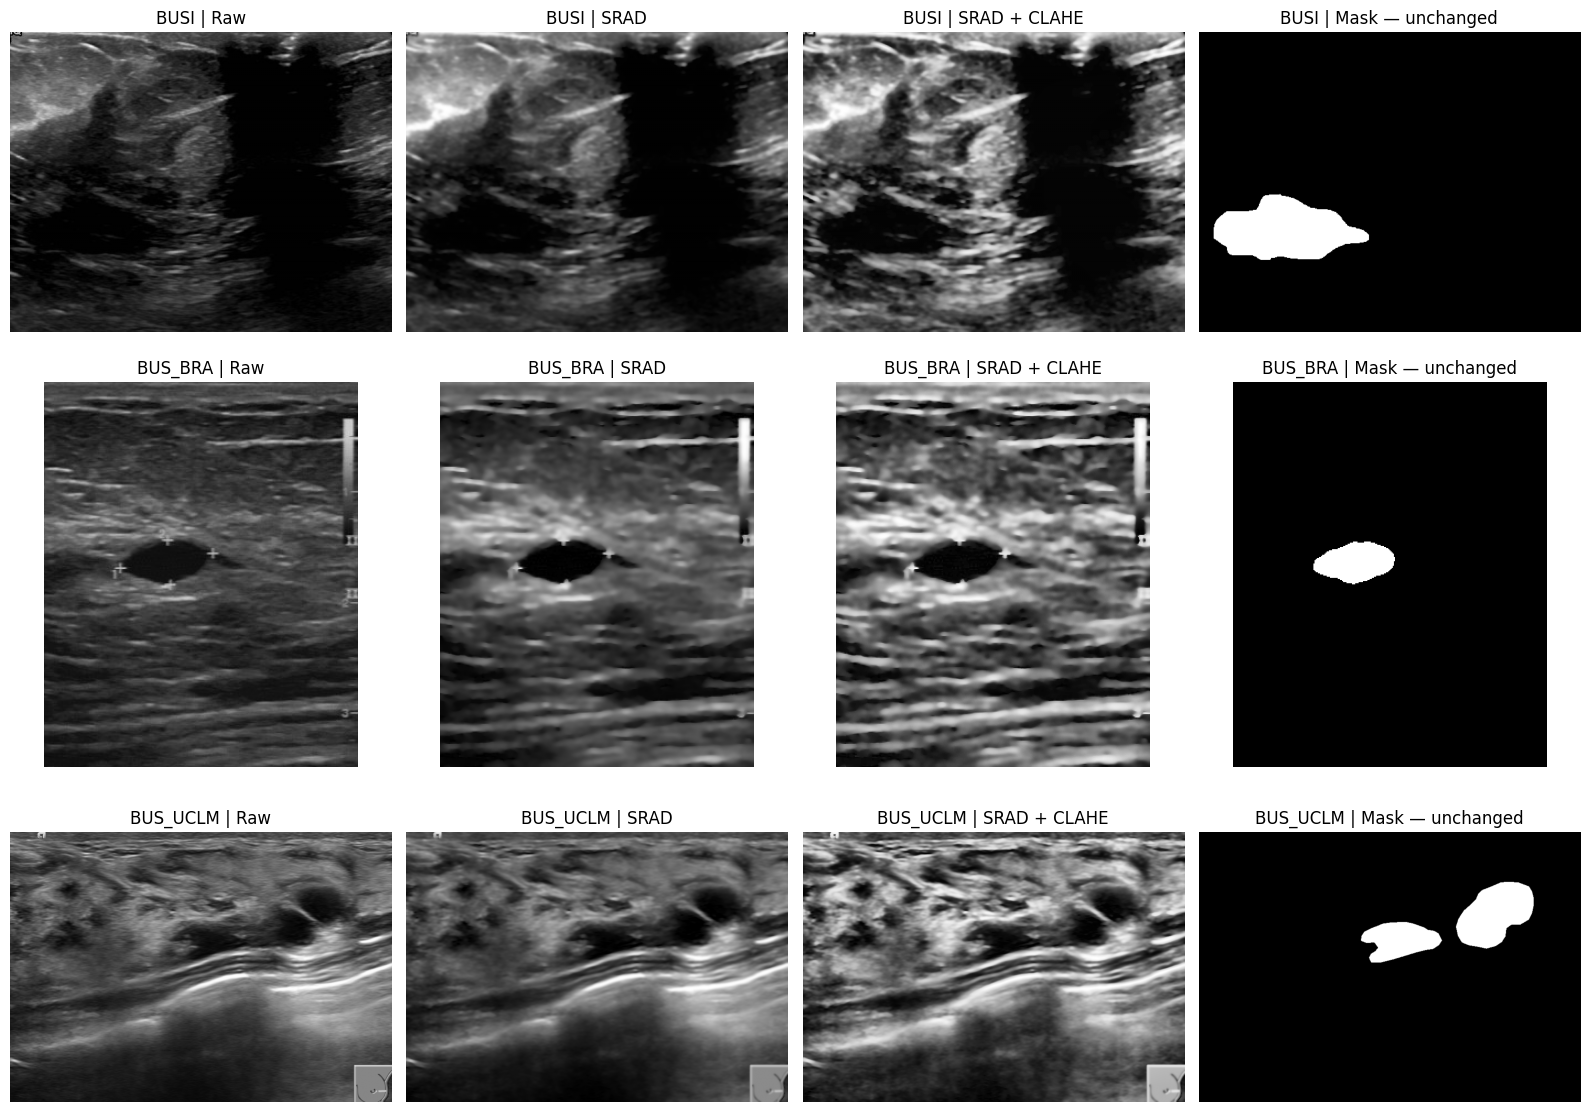

In [9]:
def show_source_examples(frame, seed=CFG.SEED):
    samples = []
    for dataset, part in frame.groupby("dataset"):
        samples.append(part.sample(1, random_state=seed))
    sample = pd.concat(samples, ignore_index=True)
    fig, axes = plt.subplots(len(sample), 4, figsize=(16, 4 * len(sample)), squeeze=False)
    for row_number, (_, row) in enumerate(sample.iterrows()):
        raw = read_gray(row.image_path)
        mask = read_binary_mask(row.mask_path)
        despeckled, enhanced = preprocess_image(raw)
        for column, (image, title) in enumerate([
            (raw, "Raw"), (despeckled, "SRAD"),
            (enhanced, "SRAD + CLAHE"), (mask, "Mask — unchanged")
        ]):
            axes[row_number, column].imshow(image, cmap="gray", vmin=0, vmax=255)
            axes[row_number, column].set_title(f"{row.dataset} | {title}")
            axes[row_number, column].axis("off")
    plt.tight_layout()
    plt.show()


show_source_examples(split_manifest)


## 8. Export

Exports locally and uploads train, validation and test as Parquet shards.


In [10]:
def export_partition(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    records = []
    for _, row in tqdm(frame.iterrows(), total=len(frame), desc=f"Exporting {split_name}"):
        raw = read_gray(row.image_path)
        mask = read_binary_mask(row.mask_path)
        if raw.shape != mask.shape:
            raise ValueError(f"Geometry changed after audit: {row.image_id}")
        despeckled, enhanced = preprocess_image(raw)

        base = OUTPUT_ROOT / "dataset" / split_name / row.dataset
        paths = {
            "raw_path": base / "raw" / f"{row.image_id}.png",
            "srad_path": base / "srad" / f"{row.image_id}.png",
            "enhanced_path": base / "enhanced" / f"{row.image_id}.png",
            "mask_path_exported": base / "masks" / f"{row.image_id}.png",
        }
        write_png(paths["raw_path"], raw)
        write_png(paths["srad_path"], despeckled)
        write_png(paths["enhanced_path"], enhanced)
        write_png(paths["mask_path_exported"], mask)
        records.append({
            **row.to_dict(),
            **{key: str(value.relative_to(OUTPUT_ROOT)) for key, value in paths.items()},
            "srad_iterations": CFG.SRAD_ITERATIONS,
            "srad_step": CFG.SRAD_STEP,
            "srad_decay": CFG.SRAD_DECAY,
            "clahe_clip_limit": CFG.CLAHE_CLIP_LIMIT,
            "clahe_grid": "x".join(map(str, CFG.CLAHE_GRID)),
        })
    return pd.DataFrame(records)


if CFG.RUN_FULL_EXPORT:
    exported = []
    for split_name, part in combined_splits.items():
        exported.append(export_partition(part, split_name))
    export_manifest = pd.concat(exported, ignore_index=True)
    export_manifest.to_csv(OUTPUT_ROOT / "preprocessing_manifest.csv", index=False)
    (OUTPUT_ROOT / "preprocessing_config.json").write_text(
        json.dumps(asdict(CFG), indent=2), encoding="utf-8"
    )
    print(f"Finished: {len(export_manifest)} images exported.")

    if CFG.UPLOAD_TO_HF:
        create_repo(
            repo_id=CFG.HF_REPO_ID,
            repo_type="dataset",
            private=CFG.HF_PRIVATE,
            exist_ok=True,
            token=HF_TOKEN,
        )
        split_names = {
            "train": "train",
            "val": "validation",
            "internal_test": "test",
        }
        hub_splits = {}

        for local_split, hub_split in split_names.items():
            table = export_manifest.loc[export_manifest["split"].eq(local_split)].copy()
            table["image"] = table["enhanced_path"].map(lambda p: str(OUTPUT_ROOT / p))
            table["mask"] = table["mask_path_exported"].map(lambda p: str(OUTPUT_ROOT / p))
            columns = [
                "image_id", "dataset", "patient_id", "group_quality", "class_label",
                "image", "mask", "srad_iterations", "srad_step", "srad_decay",
                "clahe_clip_limit", "clahe_grid",
            ]
            dataset = HFDataset.from_pandas(table[columns], preserve_index=False)
            dataset = dataset.cast_column("image", HFImage())
            dataset = dataset.cast_column("mask", HFImage())
            hub_splits[hub_split] = dataset

        DatasetDict(hub_splits).push_to_hub(
            repo_id=CFG.HF_REPO_ID,
            private=CFG.HF_PRIVATE,
            token=HF_TOKEN,
            max_shard_size="100MB",
            commit_message="Upload G17 image-mask Parquet shards",
        )
        hf_api.upload_file(
            path_or_fileobj=str(OUTPUT_ROOT / "preprocessing_manifest.csv"),
            path_in_repo="preprocessing_manifest.csv",
            repo_id=CFG.HF_REPO_ID,
            repo_type="dataset",
        )
        hf_api.upload_file(
            path_or_fileobj=str(OUTPUT_ROOT / "preprocessing_config.json"),
            path_in_repo="preprocessing_config.json",
            repo_id=CFG.HF_REPO_ID,
            repo_type="dataset",
        )
        print(f"Parquet shards uploaded to https://huggingface.co/datasets/{CFG.HF_REPO_ID}")
else:
    print("Audit-only run finished. Set RUN_FULL_EXPORT=True and rerun to export images.")


Exporting train:   0%|          | 0/1688 [00:00<?, ?it/s]

Exporting val:   0%|          | 0/420 [00:00<?, ?it/s]

Exporting internal_test:   0%|          | 0/529 [00:00<?, ?it/s]

Finished: 2637 images exported.


Uploading the dataset shards:   0%|          | 0/2 [00:00<?, ? shards/s]

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Parquet shards uploaded to https://huggingface.co/datasets/aee4/G17-preprocessed-dataset
